In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


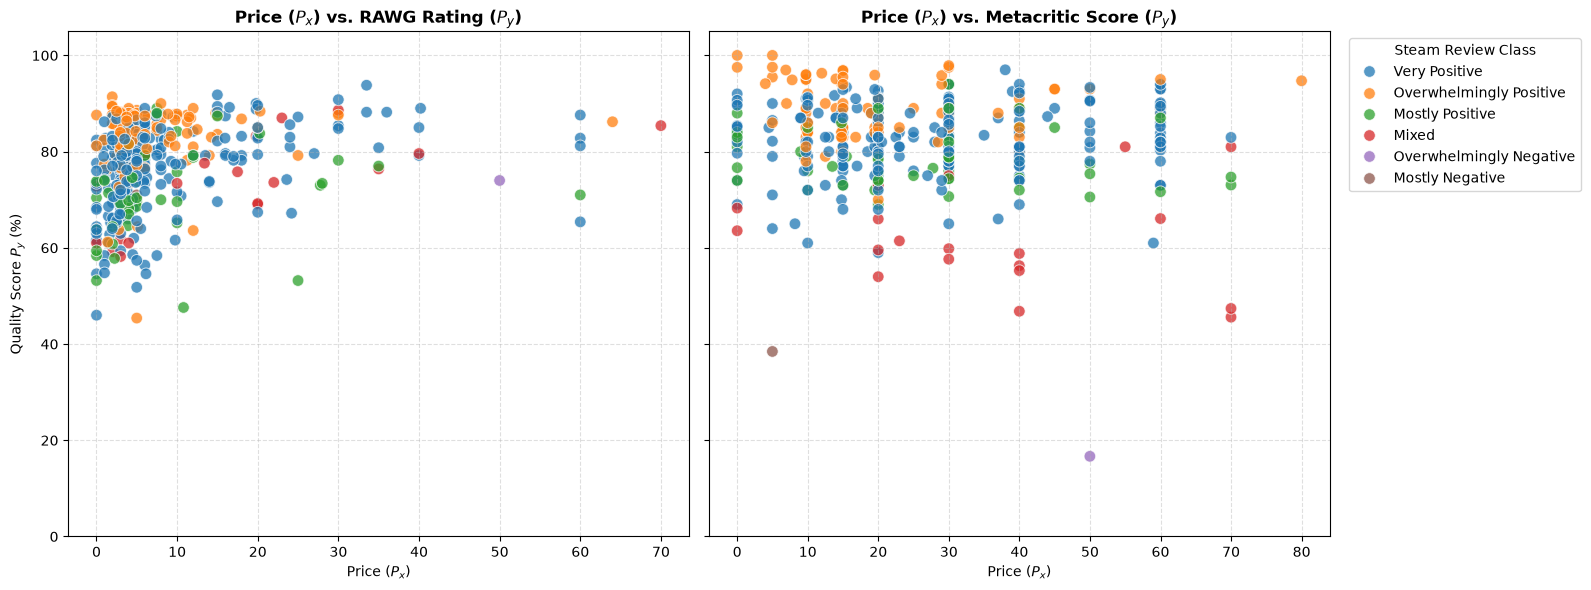

In [15]:
df = pd.read_csv("excel files\cleaned data.csv")
df["rawg_py"] = df["RAWG_Rating"] * 20
df["metacritic_py"] = df["Metacritics"]
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
custom_palette = "tab10"  

sns.scatterplot(
    data=df,
    x="Final_Price",
    y="rawg_py",
    hue="steam_rating_text",
    palette=custom_palette,
    s=70,
    alpha=0.75,
    ax=axes[0],
)
axes[0].set_title("Price ($P_x$) vs. RAWG Rating ($P_y$)", fontweight="bold")
axes[0].set_xlabel("Price ($P_x$)")
axes[0].set_ylabel("Quality Score $P_y$ (%)")
axes[0].set_ylim(0, 105)
axes[0].grid(True, linestyle="--", alpha=0.4)

sns.scatterplot(
    data=df,
    x="Initial_Price",
    y="metacritic_py",
    hue="steam_rating_text",
    palette=custom_palette,
    s=70,
    alpha=0.75,
    ax=axes[1],
)
axes[1].set_title(
    "Price ($P_x$) vs. Metacritic Score ($P_y$)", fontweight="bold"
)
axes[1].set_xlabel("Price ($P_x$)")
axes[1].set_ylabel("")  # Shared with left plot
axes[1].set_ylim(0, 105)
axes[1].grid(True, linestyle="--", alpha=0.4)

axes[0].get_legend().remove()  
axes[1].legend(
    title="Steam Review Class",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
)

plt.tight_layout()
plt.show()

C:\Users\silyo\AppData\Local\Temp\ipykernel_2500\1239962484.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


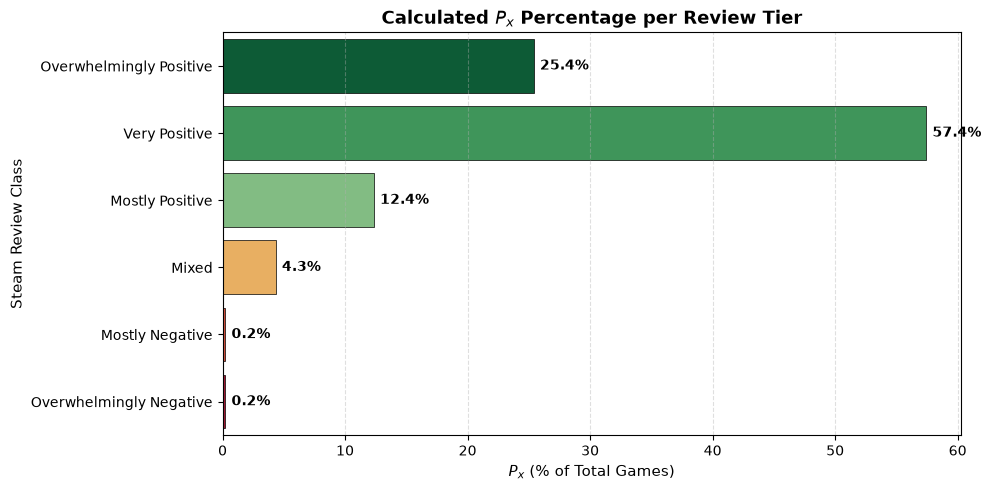

In [40]:
# 1. Define target review class ordering
review_order = [
    "Overwhelmingly Positive",
    "Very Positive",
    "Mostly Positive",
    "Mixed",
    "Mostly Negative",
    "Overwhelmingly Negative"
]

# High-contrast greens for positive tiers
palette = ["#006837", "#31a354", "#78c679", "#feb24c", "#f03b20", "#bd0026"]
px_series = (df["steam_rating_text"].value_counts() / len(df)) * 100
px_df = px_series.reset_index()
px_df.columns = ["steam_rating_text", "Px_percentage"]

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=px_df,
    x="Px_percentage",           
    y="steam_rating_text",
    order=review_order,
    palette=palette,
    edgecolor="black",
    linewidth=0.5
)

for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(
            f"{width:.1f}%",
            (width + 0.5, p.get_y() + p.get_height() / 2.0),
            ha="left",
            va="center",
            fontsize=10,
            fontweight="bold"
        )

plt.title("Calculated $P_x$ Percentage per Review Tier", fontsize=13, fontweight="bold")
plt.xlabel("$P_x$ (% of Total Games)", fontsize=11)
plt.ylabel("Steam Review Class", fontsize=11)
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

Most of games positive but the worthiness will be function by high ratings depending on pricing and popularity 

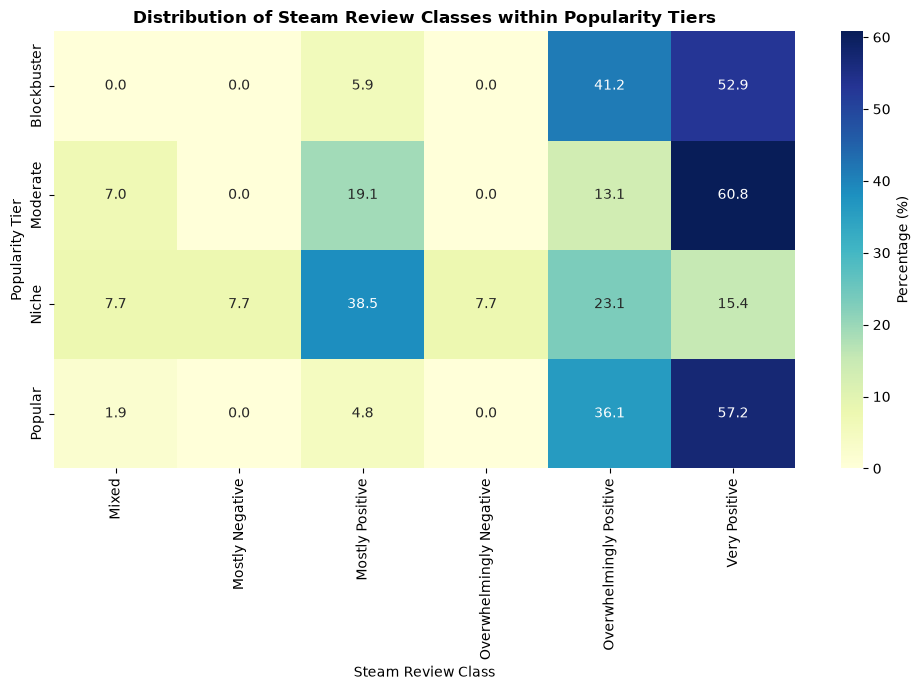

In [14]:
ct = pd.crosstab(
    df["Popularity"], 
    df["steam_rating_text"], 
    normalize="index"  
) * 100

plt.figure(figsize=(10, 7))
sns.heatmap(ct, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Percentage (%)'})
plt.title("Distribution of Steam Review Classes within Popularity Tiers", fontweight="bold")
plt.xlabel("Steam Review Class")
plt.ylabel("Popularity Tier")
plt.tight_layout()
plt.show()

We aim for popular and blockbuster that has positive reviews 

In [83]:
positive_classes = ["Overwhelmingly Positive", "Very Positive", "Mostly Positive"]
popular_tiers = ["Popular", "Blockbuster"]
df_filtered["combo"] = (
    df["Popularity"] + " | " + df["steam_rating_text"]
)

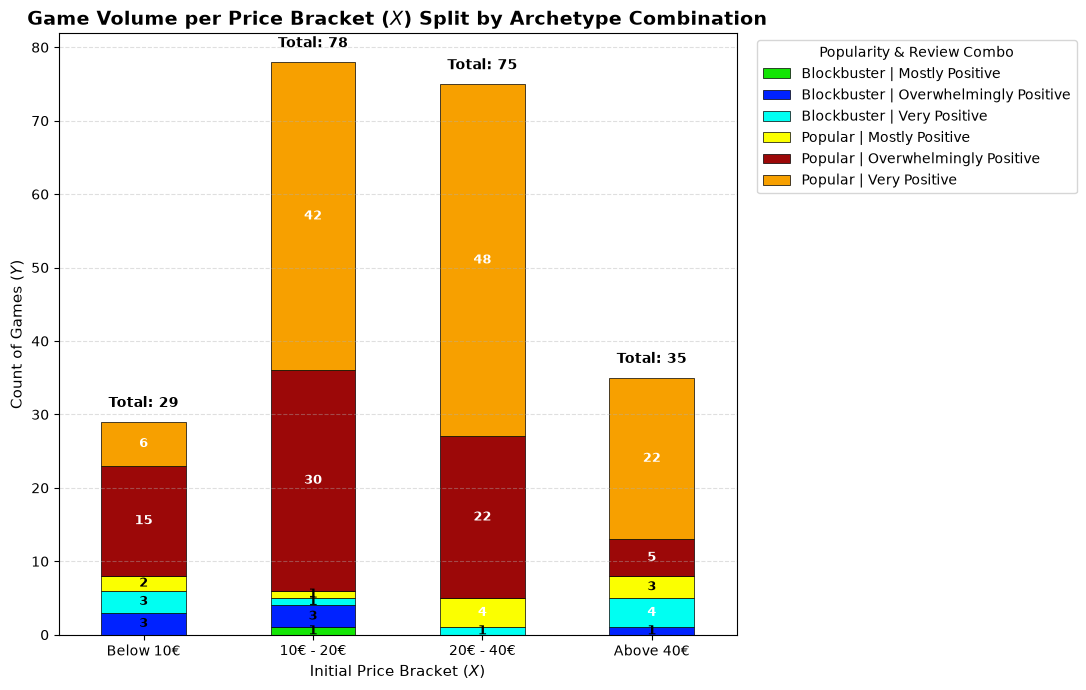

In [93]:
# 2. Bin Initial Prices into 4 explicit classes for the X-axis
price_bins = [-1, 10, 20, 40, float("inf")]
price_labels = ["Below 10€", "10€ - 20€", "20€ - 40€", "Above 40€"]

df_filtered["price_tier"] = pd.cut(
    df_filtered["Initial_Price"],
    bins=price_bins,
    labels=price_labels,
    right=False
)

# 4. Create contingency table: Price Tiers on X, Archetype Combos stacked inside legend
counts_matrix = pd.crosstab(df_filtered["price_tier"], df_filtered["combo"])

# Ensure X-axis follows price ordering from lowest to highest
counts_matrix = counts_matrix.reindex(price_labels)

# 5. Plot Vertical Stacked Bar Chart
fig, ax = plt.subplots(figsize=(11, 7))

# 6 distinct colors for the archetype combinations in the legend
palette = [
    "#13e504","#0022FF","#00fff2",
    "#fbff00","#9c0808", "#f7a000"
]

counts_matrix.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=palette[:counts_matrix.shape[1]],
    edgecolor="black",
    linewidth=0.5
)

# 6. Annotate game counts directly inside each stacked segment
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 0:  # Only label non-zero segments
            x_pos = bar.get_x() + bar.get_width() / 2.0
            y_pos = bar.get_y() + height / 2.0
            
            # Text color adjustment based on segment height/fill
            ax.annotate(
                f"{int(height)}",
                (x_pos, y_pos),
                ha="center",
                va="center",
                color="white" if height > 3 else "black",
                fontweight="bold",
                fontsize=9
            )

# Annotate total game count above each price bracket bar
for i, total in enumerate(counts_matrix.sum(axis=1)):
    if total > 0:
        ax.annotate(
            f"Total: {int(total)}",
            (i, total + max(counts_matrix.sum(axis=1)) * 0.02),
            ha="center",
            va="bottom",
            fontweight="bold",
            fontsize=10
        )

plt.title("Game Volume per Price Bracket ($X$) Split by Archetype Combination", fontsize=14, fontweight="bold")
plt.xlabel("Initial Price Bracket ($X$)", fontsize=11)
plt.ylabel("Count of Games ($Y$)", fontsize=11)
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.4)

# Place legend cleanly outside plot area
plt.legend(
    title="Popularity & Review Combo", 
    bbox_to_anchor=(1.02, 1), 
    loc="upper left",
    frameon=True
)

plt.tight_layout()
plt.show()

Popular games with positive reviews has contributated in between 10 and 40 euro without discount especially [10,20] while blockbuster has more positive reviews below 10 euro 

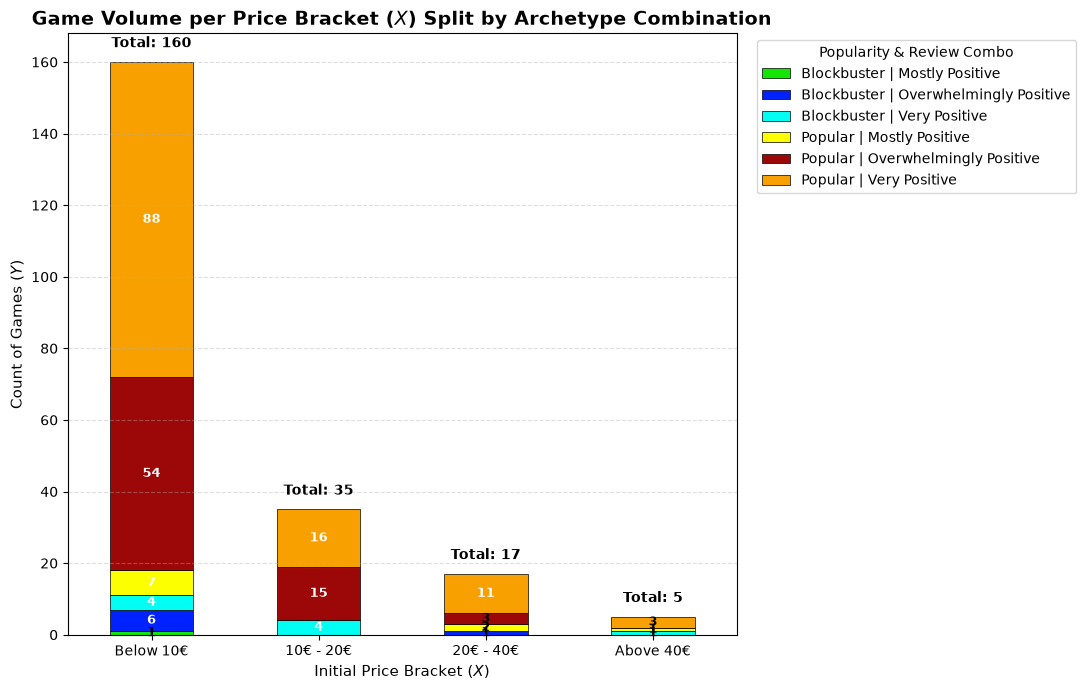

In [94]:
# 2. Bin Initial Prices into 4 explicit classes for the X-axis
price_bins = [-1, 10, 20, 40, float("inf")]
price_labels = ["Below 10€", "10€ - 20€", "20€ - 40€", "Above 40€"]

df_filtered["price_tier"] = pd.cut(
    df_filtered["Final_Price"],
    bins=price_bins,
    labels=price_labels,
    right=False
)

# 4. Create contingency table: Price Tiers on X, Archetype Combos stacked inside legend
counts_matrix = pd.crosstab(df_filtered["price_tier"], df_filtered["combo"])

# Ensure X-axis follows price ordering from lowest to highest
counts_matrix = counts_matrix.reindex(price_labels)

# 5. Plot Vertical Stacked Bar Chart
fig, ax = plt.subplots(figsize=(11, 7))

# 6 distinct colors for the archetype combinations in the legend
palette = [
    "#13e504","#0022FF","#00fff2",
    "#fbff00","#9c0808", "#f7a000"
]

counts_matrix.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=palette[:counts_matrix.shape[1]],
    edgecolor="black",
    linewidth=0.5
)

# 6. Annotate game counts directly inside each stacked segment
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 0:  # Only label non-zero segments
            x_pos = bar.get_x() + bar.get_width() / 2.0
            y_pos = bar.get_y() + height / 2.0
            
            # Text color adjustment based on segment height/fill
            ax.annotate(
                f"{int(height)}",
                (x_pos, y_pos),
                ha="center",
                va="center",
                color="white" if height > 3 else "black",
                fontweight="bold",
                fontsize=9
            )

# Annotate total game count above each price bracket bar
for i, total in enumerate(counts_matrix.sum(axis=1)):
    if total > 0:
        ax.annotate(
            f"Total: {int(total)}",
            (i, total + max(counts_matrix.sum(axis=1)) * 0.02),
            ha="center",
            va="bottom",
            fontweight="bold",
            fontsize=10
        )

plt.title("Game Volume per Price Bracket ($X$) Split by Archetype Combination", fontsize=14, fontweight="bold")
plt.xlabel("Initial Price Bracket ($X$)", fontsize=11)
plt.ylabel("Count of Games ($Y$)", fontsize=11)
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.4)

# Place legend cleanly outside plot area
plt.legend(
    title="Popularity & Review Combo", 
    bbox_to_anchor=(1.02, 1), 
    loc="upper left",
    frameon=True
)

plt.tight_layout()
plt.show()

Popular games with positive reviews has contributated below 10 euro as well as discount, so the question is the reviews are good because of the discount or because of how good is the game?